In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
train_csv = pd.read_csv("data/train.csv")
oil_csv = pd.read_csv("data/oil.csv")

In [3]:
oil_csv['dcoilwtico'].values

array([  nan, 93.14, 92.97, ..., 46.46, 45.96, 47.26], shape=(1218,))

In [4]:
oil_csv['dcoilwtico'] = oil_csv['dcoilwtico'].ffill()
oil_csv['dcoilwtico'] = oil_csv['dcoilwtico'].bfill()

In [5]:
oil_csv['dcoilwtico'].isna().sum()

np.int64(0)

In [6]:
oil_csv['dcoilwtico']

0       93.14
1       93.14
2       92.97
3       93.12
4       93.20
        ...  
1213    47.65
1214    46.40
1215    46.46
1216    45.96
1217    47.26
Name: dcoilwtico, Length: 1218, dtype: float64

In [7]:
oil_prices = []
for index,val in enumerate(range(len(oil_csv))):
    date = oil_csv.iloc[index,0]
    oil_price = oil_csv.iloc[index,1]
    for index,v in enumerate(range(len(oil_csv))):
        train_date = train_csv.iloc[index,1]
        if train_date == date:
            oil_prices.append(oil_price)

In [8]:
train_csv = train_csv.merge(oil_csv, on='date', how='left')

In [9]:
stores_csv = pd.read_csv("data/stores.csv")

In [10]:
train_csv = train_csv.merge(stores_csv,on="store_nbr", how="left")

In [11]:
train_csv

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.000,0,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.000,0,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.000,0,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.000,0,93.14,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,47.57,Quito,Pichincha,B,6
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57,Quito,Pichincha,B,6
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,47.57,Quito,Pichincha,B,6
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57,Quito,Pichincha,B,6


In [12]:
transactions_csv = pd.read_csv("data/transactions.csv")

In [13]:
train_csv.head(10)

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,93.14,Quito,Pichincha,D,13
6,6,2013-01-01,1,CELEBRATION,0.0,0,93.14,Quito,Pichincha,D,13
7,7,2013-01-01,1,CLEANING,0.0,0,93.14,Quito,Pichincha,D,13
8,8,2013-01-01,1,DAIRY,0.0,0,93.14,Quito,Pichincha,D,13
9,9,2013-01-01,1,DELI,0.0,0,93.14,Quito,Pichincha,D,13


In [14]:
holiday_csv = pd.read_csv("data/holidays_events.csv")
national_holidays = holiday_csv[holiday_csv["locale"] == "National"]

In [15]:
national_holidays["type"].value_counts()

type
Holiday       60
Event         56
Additional    40
Transfer       8
Bridge         5
Work Day       5
Name: count, dtype: int64

In [16]:
national_holidays.isna().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [17]:
train_csv = train_csv.merge(national_holidays,on="date",how="left")

In [18]:
train_csv.head(5)

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False


In [19]:
train_csv.isna().sum()

id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
dcoilwtico      862488
city                 0
state                0
type_x               0
cluster              0
type_y         2746062
locale         2746062
locale_name    2746062
description    2746062
transferred    2746062
dtype: int64

In [20]:
holiday_csv["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [21]:
regional_holidays = holiday_csv[holiday_csv['locale'] == 'Regional'][['date', 'locale_name', 'type']]
regional_holidays = regional_holidays.rename(columns={'type': 'regional_holiday_type'})
train_csv = train_csv.merge(regional_holidays, left_on=['date', 'state'], right_on=['date', 'locale_name'], how='left')

local_holidays = holiday_csv[holiday_csv['locale'] == 'Local'][['date', 'locale_name', 'type']]
local_holidays = local_holidays.rename(columns={'type': 'local_holiday_type'})
train_csv = train_csv.merge(local_holidays, left_on=['date', 'city'], right_on=['date', 'locale_name'], how='left')

In [22]:
train_csv.isna().sum()

id                             0
date                           0
store_nbr                      0
family                         0
sales                          0
onpromotion                    0
dcoilwtico                862752
city                           0
state                          0
type_x                         0
cluster                        0
type_y                   2746326
locale                   2746326
locale_name_x            2746326
description              2746326
transferred              2746326
locale_name_y            3007257
regional_holiday_type    3007257
locale_name              2995773
local_holiday_type       2995773
dtype: int64

In [23]:
transactions_csv = pd.read_csv("data/transactions.csv")
train_csv = train_csv.merge(transactions_csv, on=['date', 'store_nbr'], how='left')

In [24]:
train_csv = train_csv.drop(columns=['locale_name_x', 'locale_name_y'])
train_csv = train_csv.rename(columns={'type_x': 'store_type', 'type_y': 'national_holiday_type'})

In [25]:
train_csv['national_holiday_type'] = train_csv['national_holiday_type'].fillna('None')
train_csv['regional_holiday_type'] = train_csv['regional_holiday_type'].fillna('None')
train_csv['local_holiday_type'] = train_csv['local_holiday_type'].fillna('None')

In [26]:
train_csv['is_holiday'] = (train_csv['national_holiday_type'] != 'None').astype(int)

In [27]:
train_csv['dcoilwtico'] = train_csv['dcoilwtico'].interpolate(method='linear')

<Axes: xlabel='date'>

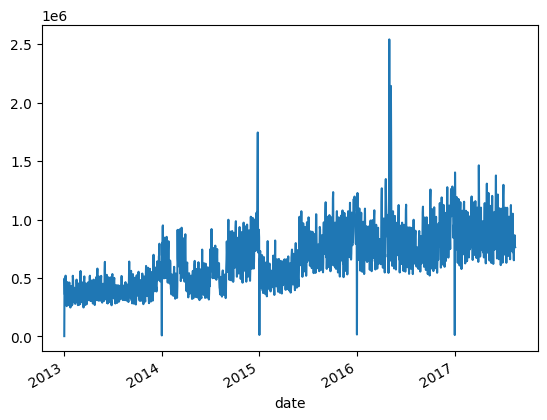

In [28]:
train_csv['date'] = pd.to_datetime(train_csv['date'])
train_csv.groupby('date')['sales'].sum().plot()

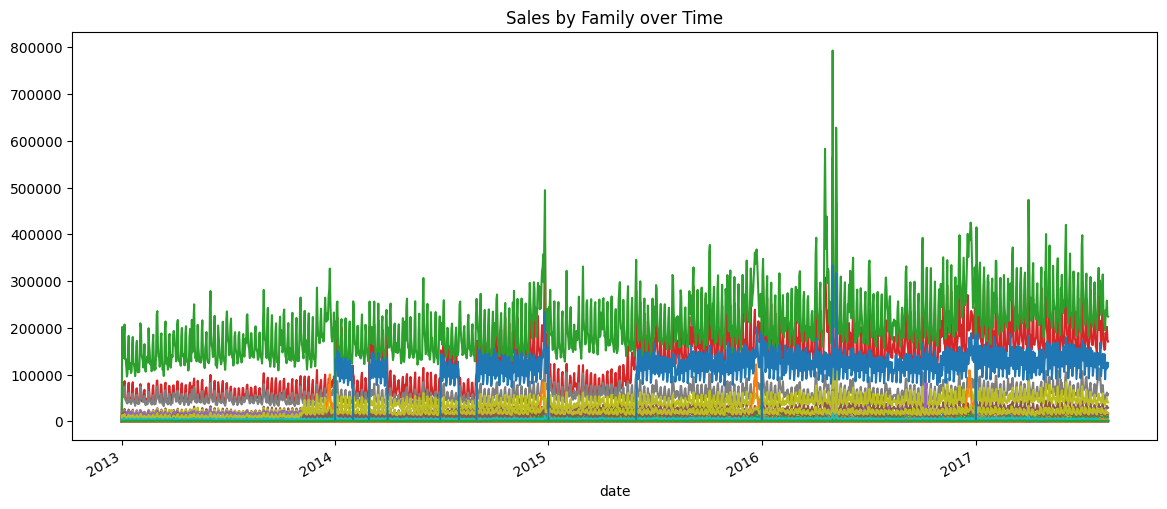

              date national_holiday_type
2136618 2016-04-16                 Event
Empty DataFrame
Columns: [date, national_holiday_type]
Index: []


In [29]:
train_csv.groupby(['date', 'family'])['sales'].sum().unstack().plot(figsize=(14,6), legend=False)
plt.title('Sales by Family over Time')
plt.show()

dip_dates = ['2016-04-16', '2014-12-25']  
for d in dip_dates:
    print(train_csv[train_csv['date'] == d][['date', 'national_holiday_type']].head(1))

In [30]:
train_csv[train_csv['date'].astype(str).str.contains('2014-12')]['national_holiday_type'].value_counts()

national_holiday_type
None          39204
Additional    10692
Event          1782
Work Day       1782
Bridge         1782
Name: count, dtype: int64

In [31]:
train_csv = train_csv.drop(columns=['locale', 'description', 'transferred', 'locale_name'])

In [32]:
train_csv['transactions'] = train_csv['transactions'].fillna(0)

In [33]:
train_csv.isna().sum()

id                       0
date                     0
store_nbr                0
family                   0
sales                    0
onpromotion              0
dcoilwtico               0
city                     0
state                    0
store_type               0
cluster                  0
national_holiday_type    0
regional_holiday_type    0
local_holiday_type       0
transactions             0
is_holiday               0
dtype: int64

In [34]:
train_csv['year'] = train_csv['date'].dt.year
train_csv['month'] = train_csv['date'].dt.month
train_csv['day_of_week'] = train_csv['date'].dt.dayofweek
train_csv['week_of_year'] = train_csv['date'].dt.isocalendar().week.astype(int)

train_csv = train_csv.sort_values(['store_nbr', 'family', 'date'])
train_csv['sales_lag_7'] = train_csv.groupby(['store_nbr', 'family'])['sales'].shift(7)
train_csv['sales_lag_14'] = train_csv.groupby(['store_nbr', 'family'])['sales'].shift(14)

train_csv['sales_rolling_7'] = train_csv.groupby(['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())

In [35]:
train_csv.head(5)

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,store_type,...,local_holiday_type,transactions,is_holiday,year,month,day_of_week,week_of_year,sales_lag_7,sales_lag_14,sales_rolling_7
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.140000,Quito,Pichincha,D,...,None,0.0,1,2013,1,1,1,NaN,NaN,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,93.140000,Quito,Pichincha,D,...,None,2111.0,0,2013,1,2,1,NaN,NaN,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,92.970000,Quito,Pichincha,D,...,None,1833.0,0,2013,1,3,1,NaN,NaN,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,93.120000,Quito,Pichincha,D,...,None,1863.0,0,2013,1,4,1,NaN,NaN,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,93.120022,Quito,Pichincha,D,...,None,1509.0,1,2013,1,5,1,NaN,NaN,NaN


In [36]:
train_csv.isna().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                        0
onpromotion                  0
dcoilwtico                   0
city                         0
state                        0
store_type                   0
cluster                      0
national_holiday_type        0
regional_holiday_type        0
local_holiday_type           0
transactions                 0
is_holiday                   0
year                         0
month                        0
day_of_week                  0
week_of_year                 0
sales_lag_7              12474
sales_lag_14             24948
sales_rolling_7          12474
dtype: int64

In [37]:
train_csv = train_csv.dropna(subset=['sales_lag_7', 'sales_lag_14', 'sales_rolling_7'])

In [42]:
train_csv['sales_lag_28'] = train_csv.groupby(['store_nbr', 'family'])['sales'].shift(28)
train_csv['sales_lag_35'] = train_csv.groupby(['store_nbr', 'family'])['sales'].shift(35)
train_csv['sales_rolling_14'] = train_csv.groupby(['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(14).mean())
train_csv['sales_rolling_28'] = train_csv.groupby(['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(28).mean())
train_csv['day_of_month'] = pd.to_datetime(train_csv['date']).dt.day
train_csv['is_month_start'] = pd.to_datetime(train_csv['date']).dt.is_month_start.astype(int)
train_csv['is_month_end'] = pd.to_datetime(train_csv['date']).dt.is_month_end.astype(int)

In [43]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['family', 'city', 'state', 'store_type', 'national_holiday_type', 'regional_holiday_type', 'local_holiday_type']
enc = OrdinalEncoder()
train_csv[cat_cols] = enc.fit_transform(train_csv[cat_cols])

drop_cols = ['id', 'date', 'sales']
X = train_csv.drop(columns=drop_cols)
y = train_csv['sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [44]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, early_stopping_rounds=10)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

[0]	validation_0-rmse:1654.11346
[50]	validation_0-rmse:421.08528
[100]	validation_0-rmse:391.17338
[121]	validation_0-rmse:390.74206
RMSE: 389.7110879806416


<Axes: >

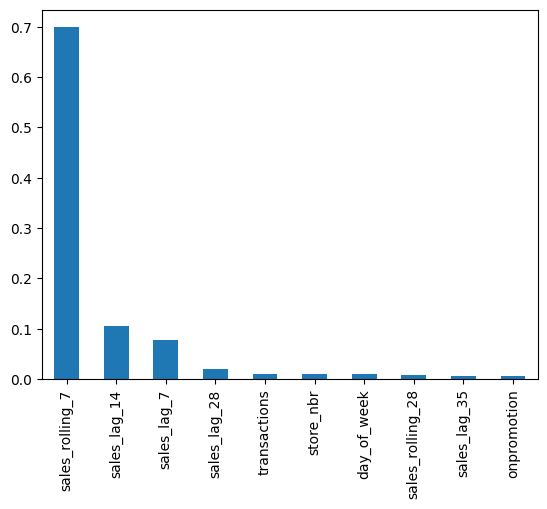

In [45]:
import pandas as pd
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')